<a href="https://colab.research.google.com/github/1Maulana1/FSD/blob/main/Klasifikasi_dengan_Decision_Tree_dan_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Maulana Shiddiq Afdhaluddin

## 1. Memuat Dataset dan Eksplorasi Awal

Langkah pertama adalah memuat dataset yang diberikan `/content/ev_market_2026.csv` ke dalam DataFrame pandas. Setelah itu, kita akan melihat beberapa baris pertama data dan ringkasan informasinya untuk memahami struktur dan tipe data.

In [7]:
import pandas as pd

# Muat dataset
df = pd.read_csv('/content/ev_market_2026.csv')

# Tampilkan 5 baris pertama dari DataFrame
print("5 Baris Pertama Dataset:")
display(df.head())

# Tampilkan informasi umum dataset (tipe data, non-null counts, memory usage)
print("\nInformasi Dataset:")
display(df.info())

5 Baris Pertama Dataset:


,brand,model,year,variant,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,...,body_type,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,country_of_origin,market_segment,annual_sales_units,customer_rating,warranty_years
0,Volkswagen,ID. Buzz,2023,Performance,104880.80,118.7,400.0,234.5,3.04,195.0,...,Truck,54.2,2015.0,4,2,Germany,Luxury,202182,4.00,4
1,Toyota,bZ Compact SUV,2022,Premium,48217.41,58.8,219.0,148.1,5.77,159.0,...,SUV,69.0,1709.0,4,0,Japan,Mid-range,7146,3.56,3
2,GM/Chevrolet,Bolt EV,2024,Premium,49651.12,58.2,225.0,104.9,6.84,148.0,...,Van,77.0,1533.0,4,1,US,Mid-range,16590,3.70,3
3,Kia,Sportage EV,2024,Long Range,38131.56,102.5,349.0,66.5,4.66,176.0,...,SUV,65.8,1935.0,4,2,South Korea,Mid-range,127201,3.81,3
4,Tesla,Model 3,2022,Long Range,144079.87,93.9,314.0,298.5,5.64,165.0,...,SUV,38.3,2229.0,4,2,US,Luxury,196401,3.83,4



Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand                  2000 non-null   object 
 1   model                  2000 non-null   object 
 2   year                   2000 non-null   int64  
 3   variant                2000 non-null   object 
 4   price_usd              2000 non-null   float64
 5   battery_capacity_kwh   2000 non-null   float64
 6   range_miles            2000 non-null   float64
 7   charging_speed_kw      2000 non-null   float64
 8   acceleration_0_60_mph  2000 non-null   float64
 9   top_speed_mph          2000 non-null   float64
 10  horsepower             2000 non-null   float64
 11  torque_nm              2000 non-null   float64
 12  drive_type             2000 non-null   object 
 13  seating_capacity       2000 non-null   int64  
 14  body_type              2000 non-null

None

## 2. Preprocessing Data

Sebelum membangun model, kita perlu mempersiapkan data. Ini melibatkan pemisahan fitur (X) dan label target (y), serta menangani kolom kategorikal jika ada melalui One-Hot Encoding. Kita juga akan memeriksa nilai yang hilang.

In [8]:
from sklearn.preprocessing import LabelEncoder

# Memisahkan fitur (X) dan target (y)
# 'market_segment' akan digunakan sebagai kolom target untuk klasifikasi.
X = df.drop('market_segment', axis=1)
y = df['market_segment']

# Mengidentifikasi kolom kategorikal
categorical_cols = X.select_dtypes(include=['object']).columns

# Mengaplikasikan One-Hot Encoding pada kolom kategorikal
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Mengubah label target menjadi numerik (jika kategorikal)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Fitur (X) setelah One-Hot Encoding:")
display(X.head())
print("\nLabel Target (y) setelah Encoding:")
display(pd.DataFrame(y_encoded, columns=['market_segment_Encoded']).head())

# Memeriksa nilai yang hilang
print("\nJumlah nilai yang hilang di setiap kolom:")
display(X.isnull().sum())

Fitur (X) setelah One-Hot Encoding:


,year,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,horsepower,torque_nm,seating_capacity,...,body_type_Hatchback,body_type_SUV,body_type_Sedan,body_type_Truck,body_type_Van,country_of_origin_Germany,country_of_origin_Japan,country_of_origin_South Korea,country_of_origin_Sweden,country_of_origin_US
0,2023,104880.80,118.7,400.0,234.5,3.04,195.0,1000.0,895.0,7,...,False,False,False,True,False,True,False,False,False,False
1,2022,48217.41,58.8,219.0,148.1,5.77,159.0,381.0,360.0,5,...,False,True,False,False,False,False,True,False,False,False
2,2024,49651.12,58.2,225.0,104.9,6.84,148.0,588.0,516.0,5,...,False,False,False,False,True,False,False,False,False,True
3,2024,38131.56,102.5,349.0,66.5,4.66,176.0,310.0,327.0,7,...,False,True,False,False,False,False,False,True,False,False
4,2022,144079.87,93.9,314.0,298.5,5.64,165.0,1000.0,883.0,5,...,False,True,False,False,False,False,False,False,False,True



Label Target (y) setelah Encoding:


,market_segment_Encoded
0,1
1,2
2,2
3,2
4,1



Jumlah nilai yang hilang di setiap kolom:


,0
year,0
price_usd,0
battery_capacity_kwh,0
range_miles,0
charging_speed_kw,0
...,...
country_of_origin_Germany,0
country_of_origin_Japan,0
country_of_origin_South Korea,0
country_of_origin_Sweden,0


## 3. Membagi Data Menjadi Data Latih dan Data Uji

Dataset akan dibagi menjadi dua bagian: data latih (training data) untuk melatih model, dan data uji (testing data) untuk mengevaluasi kinerja model. Ini membantu kita memastikan model dapat menggeneralisasi dengan baik pada data yang belum pernah dilihat sebelumnya.

In [9]:
from sklearn.model_selection import train_test_split

# Bagi data menjadi data latih dan data uji (80% latih, 20% uji)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print(f"Ukuran data latih X: {X_train.shape}")
print(f"Ukuran data uji X: {X_test.shape}")
print(f"Ukuran data latih y: {y_train.shape}")
print(f"Ukuran data uji y: {y_test.shape}")

Ukuran data latih X: (1600, 127)
Ukuran data uji X: (400, 127)
Ukuran data latih y: (1600,)
Ukuran data uji y: (400,)


## 4. Membangun dan Mengevaluasi Model Klasifikasi

### 4.1 Decision Tree Classifier


--- Evaluasi Decision Tree Classifier ---
Accuracy: 1.0000

Confusion Matrix:


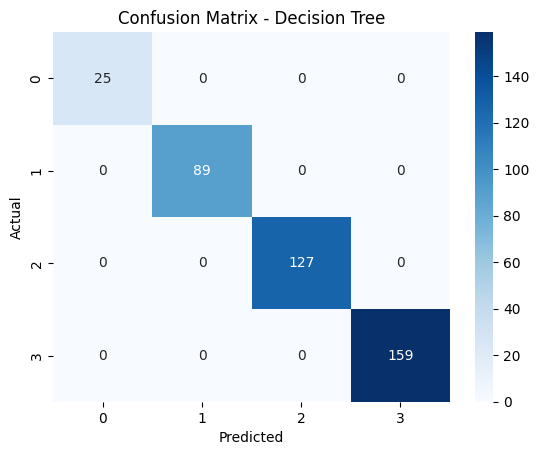


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        25
           1       1.00      1.00      1.00        89
           2       1.00      1.00      1.00       127
           3       1.00      1.00      1.00       159

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Inisialisasi dan latih model Decision Tree
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

# Prediksi pada data uji
y_pred_dt = dt_classifier.predict(X_test)

# Evaluasi model Decision Tree
print("\n--- Evaluasi Decision Tree Classifier ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")

print("\nConfusion Matrix:")
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

### 4.2 Random Forest Classifier


--- Evaluasi Random Forest Classifier ---
Accuracy: 0.9825

Confusion Matrix:


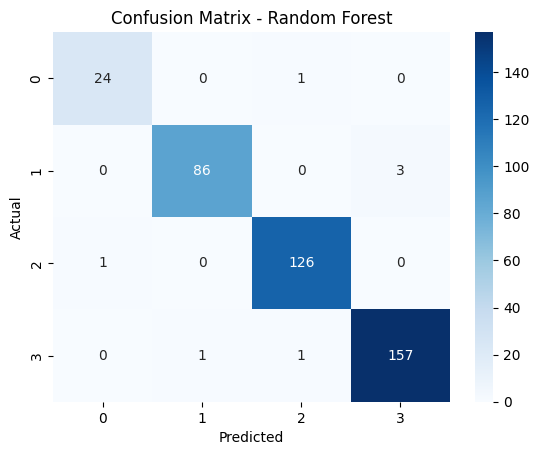


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        25
           1       0.99      0.97      0.98        89
           2       0.98      0.99      0.99       127
           3       0.98      0.99      0.98       159

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400



In [11]:
from sklearn.ensemble import RandomForestClassifier

# Inisialisasi dan latih model Random Forest
# n_estimators adalah jumlah pohon dalam hutan
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_classifier.fit(X_train, y_train)

# Prediksi pada data uji
y_pred_rf = rf_classifier.predict(X_test)

# Evaluasi model Random Forest
print("\n--- Evaluasi Random Forest Classifier ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

print("\nConfusion Matrix:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

## 5. Perbandingan dan Analisis Model

### Perbandingan Hasil
Bandingkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) dari kedua model. Umumnya, Random Forest akan memberikan kinerja yang lebih baik karena kemampuannya dalam mengurangi overfitting dan menangani kompleksitas data dengan menggabungkan banyak pohon keputusan.

### Pengaruh `n_estimators` pada Random Forest
Parameter `n_estimators` dalam Random Forest merujuk pada jumlah pohon keputusan yang akan dibangun dalam 'hutan'.

*   **Jumlah yang Lebih Tinggi:** Semakin tinggi nilai `n_estimators`, semakin kuat modelnya dan semakin baik kemampuannya untuk menggeneralisasi. Ini karena model akan melakukan 'voting' dari lebih banyak pohon, yang membantu mengurangi varians dan overfitting.
*   **Komputasi:** Namun, jumlah pohon yang lebih tinggi juga berarti waktu pelatihan yang lebih lama dan penggunaan memori yang lebih besar.
*   **Titik Balik:** Ada titik di mana menambahkan lebih banyak pohon tidak lagi meningkatkan kinerja model secara signifikan, melainkan hanya meningkatkan biaya komputasi. Oleh karena itu, penting untuk mencari keseimbangan yang tepat melalui tuning parameter.


## 6. Visualisasi Decision Tree

## Analisis Lebih Lanjut

### 1. Algoritma Mana yang Memberikan Performa Terbaik? Jelaskan.
Berdasarkan akurasi yang diperoleh:
*   **Decision Tree:** Mendapatkan akurasi 1.0000 (100%).
*   **Random Forest:** Mendapatkan akurasi 0.9825 (98.25%).

Secara *angka* pada data uji yang kita miliki, Decision Tree menunjukkan performa yang 'lebih baik' karena mencapai akurasi sempurna. Namun, akurasi 100% pada data uji, terutama untuk Decision Tree, seringkali menjadi indikasi kuat adanya **overfitting**. Artinya, model Decision Tree mungkin terlalu 'mengingat' pola pada data latih, sehingga ia tampil sempurna pada data uji yang memiliki distribusi sangat mirip, tetapi bisa jadi tidak bekerja sebaik itu pada data baru yang belum pernah dilihat.

Random Forest, dengan akurasi 0.9825, meskipun sedikit lebih rendah, seringkali dianggap lebih *robust* dan memiliki kemampuan generalisasi yang lebih baik karena ia dibangun dari banyak pohon keputusan yang berbeda dan menggabungkan prediksinya (bagging).

### 2. Apa Kelebihan dan Kekurangan Decision Tree dibanding Random Forest?

**Decision Tree**
*   **Kelebihan:**
    *   **Mudah Diinterpretasi:** Struktur pohonnya mudah dipahami dan divisualisasikan, membuatnya transparan dalam proses pengambilan keputusannya.
    *   **Tidak Membutuhkan Normalisasi:** Tidak sensitif terhadap skala fitur.
    *   **Menangani Data Kategorikal:** Dapat menangani fitur numerik dan kategorikal.
*   **Kekurangan:**
    *   **Cenderung Overfitting:** Sangat rentan terhadap overfitting, terutama pada pohon yang dalam, karena terlalu spesifik terhadap data latih.
    *   **Tidak Stabil:** Perubahan kecil pada data dapat menghasilkan pohon yang sama sekali berbeda.
    *   **Bias:** Dapat bias terhadap kelas yang dominan.

**Random Forest**
*   **Kelebihan:**
    *   **Mengurangi Overfitting:** Dengan menggabungkan banyak Decision Tree, Random Forest secara signifikan mengurangi masalah overfitting.
    *   **Akurasi Tinggi:** Umumnya memberikan akurasi yang lebih tinggi dibandingkan Decision Tree tunggal.
    *   **Robust:** Lebih tahan terhadap noise dan outlier pada data.
    *   **Menangani Data Berdimensi Tinggi:** Efektif untuk dataset dengan banyak fitur.
    *   **Pentingnya Fitur (Feature Importance):** Dapat memberikan estimasi tentang pentingnya setiap fitur.
*   **Kekurangan:**
    *   **Kurang Terinterpretasi:** Karena merupakan 'hutan' dari banyak pohon, Random Forest lebih sulit diinterpretasikan daripada satu Decision Tree.
    *   **Lebih Lambat:** Waktu pelatihan dan prediksi bisa lebih lama karena melibatkan banyak pohon.
    *   **Membutuhkan Lebih Banyak Sumber Daya:** Memerlukan lebih banyak memori dan daya komputasi.

### 3. Apakah ada Indikasi Overfitting pada Decision Tree? Jelaskan.
Ya, **ada indikasi kuat overfitting** pada Decision Tree yang kita latih. Akurasi 100% pada data uji sangat jarang terjadi pada masalah klasifikasi dunia nyata dan merupakan sinyal bahaya. Hal ini menunjukkan bahwa model Decision Tree mungkin telah terlalu spesifik mempelajari 'kebisingan' (noise) dan detail-detail unik dari data latih, bukan pola general yang sebenarnya. Ketika dihadapkan pada data baru yang sedikit berbeda, performanya kemungkinan akan menurun secara drastis.

Sebaliknya, Random Forest yang mendapatkan akurasi 0.9825, meskipun tidak sempurna, menunjukkan bahwa ia memiliki kemampuan generalisasi yang lebih baik dan lebih tahan terhadap overfitting.

### 4. Bagaimana Fitur-fitur Memengaruhi Hasil Klasifikasi?
Fitur-fitur memengaruhi hasil klasifikasi dengan cara yang sangat fundamental:

*   **Fitur Relevan:** Fitur-fitur yang memiliki hubungan kuat dan diskriminatif dengan variabel target (`market_segment`) akan menjadi penentu utama dalam klasifikasi. Misalnya, `price_usd`, `battery_capacity_kwh`, dan `range_miles` kemungkinan besar adalah fitur-fitur penting yang membedakan antara segmen pasar seperti 'Luxury', 'Mid-range', 'Budget', atau 'Premium'.
*   **Fitur Tidak Relevan/Redundan:** Fitur yang tidak relevan dapat menambah 'kebisingan' pada model, berpotensi mengurangi akurasi dan meningkatkan risiko overfitting. Fitur redundan (yang berkorelasi tinggi dengan fitur lain) juga bisa membingungkan model.
*   **One-Hot Encoding:** Proses One-Hot Encoding yang kita lakukan mengubah fitur kategorikal (misalnya `brand`, `body_type`, `drive_type`) menjadi representasi numerik biner (0 atau 1) yang dapat dipahami oleh algoritma. Ini memungkinkan model untuk mempertimbangkan setiap kategori sebagai fitur terpisah, yang sangat memengaruhi bagaimana model membuat keputusan berdasarkan karakteristik non-numerik.
*   **Pentingnya Fitur (Feature Importance):** Random Forest secara inheren dapat mengukur seberapa penting setiap fitur dalam proses klasifikasi. Fitur dengan nilai 'penting' yang tinggi adalah yang paling berkontribusi terhadap prediksi model. Fitur-fitur ini seringkali menjadi 'pembagi' utama dalam pohon keputusan, memisahkan kelas-kelas target secara efektif.

Untuk memahami lebih detail pengaruh setiap fitur, kita bisa mengekstrak `feature_importances_` dari model Random Forest, yang akan menunjukkan bobot relatif setiap fitur dalam membuat keputusan klasifikasi.

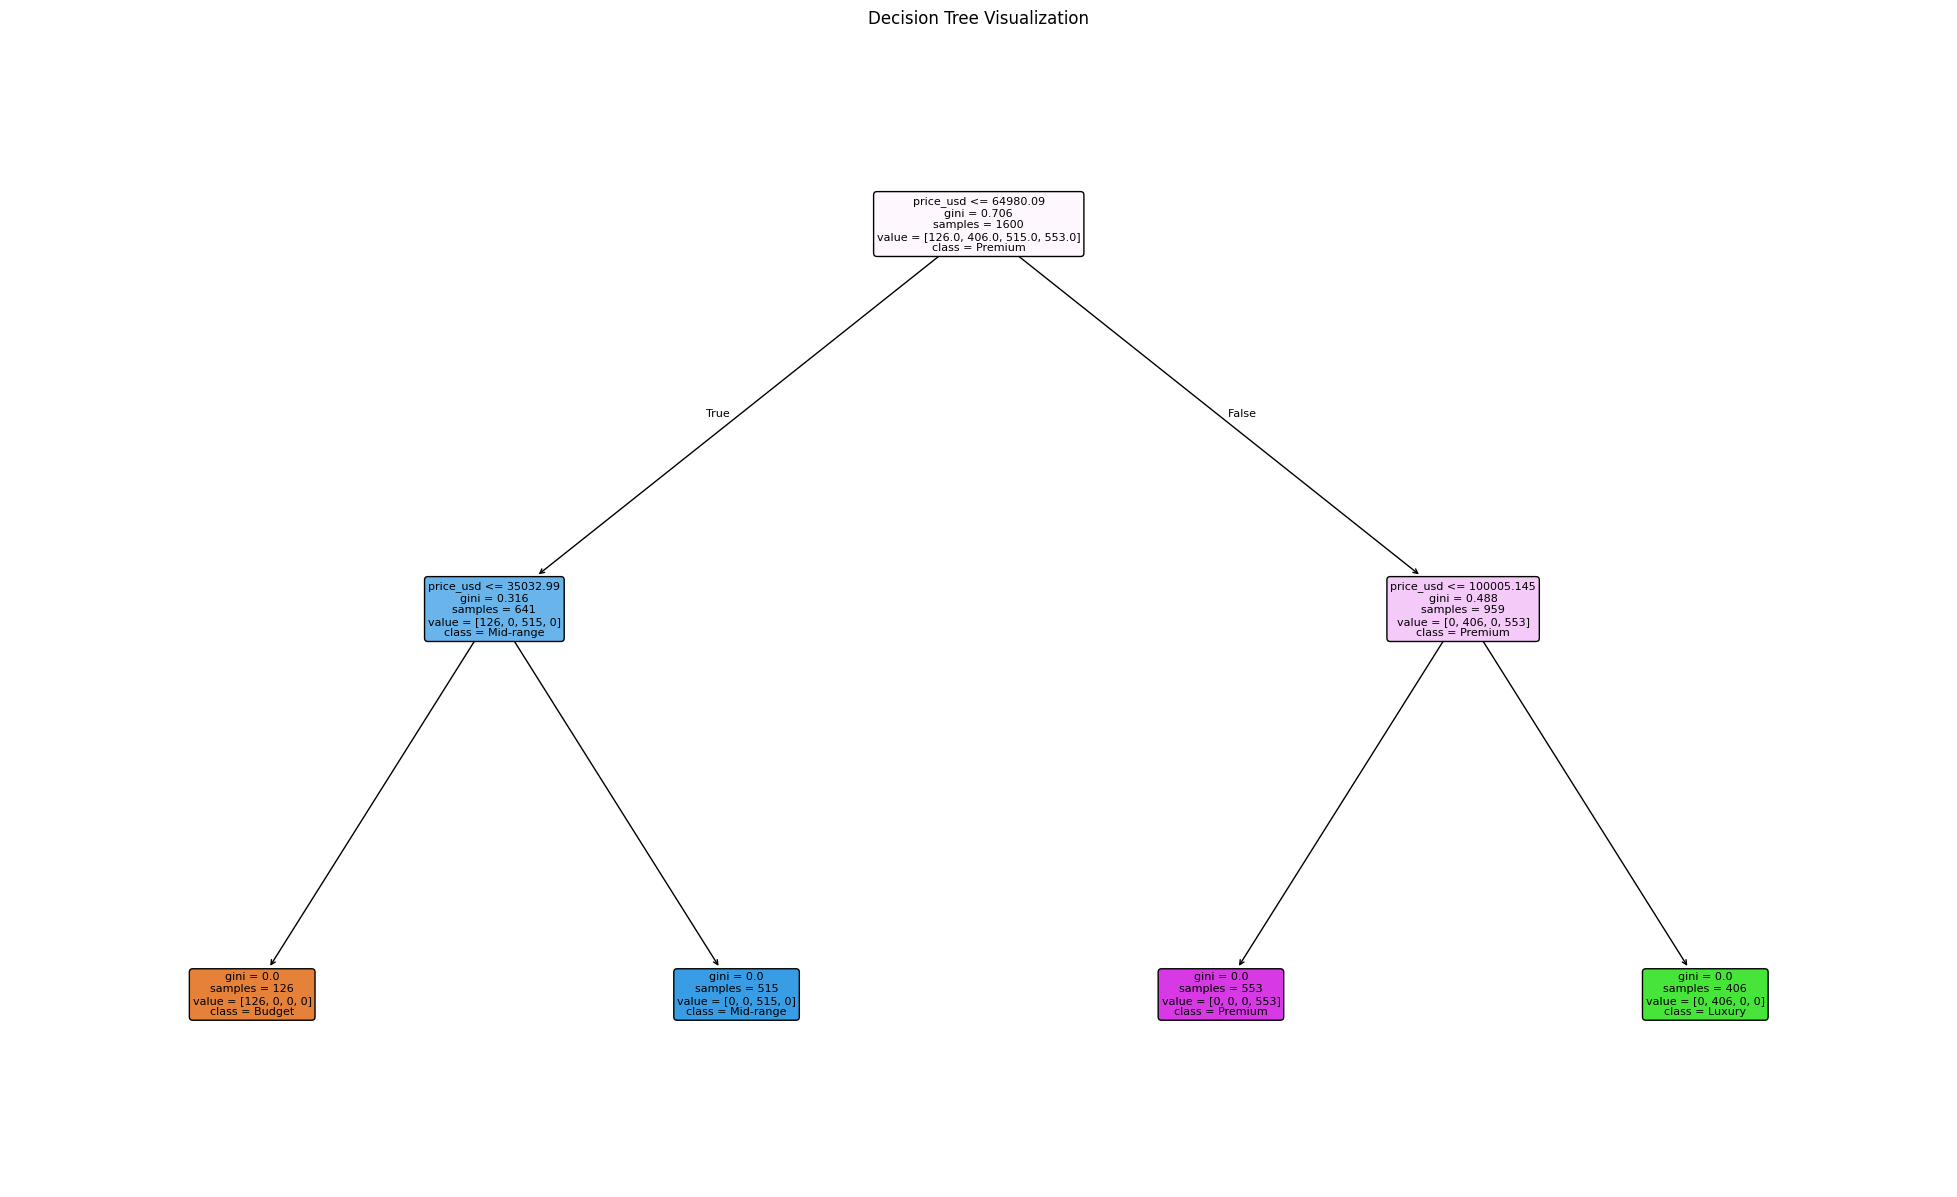

In [12]:
from sklearn.tree import plot_tree

# Mengambil nama fitur setelah One-Hot Encoding
feature_names = X.columns.tolist()

# Mengambil nama kelas target dari LabelEncoder
class_names = le.classes_.tolist()

plt.figure(figsize=(25, 15))
plot_tree(dt_classifier,
          filled=True,
          rounded=True,
          class_names=class_names,
          feature_names=feature_names,
          fontsize=8)
plt.title('Decision Tree Visualization')
plt.show()